In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
FEATURE_COLS = [
    'total_orders', 'total_spend', 'avg_order_value', 'max_order_value',
    'min_order_value', 'customer_age_days', 'avg_review_score',
    'avg_delivery_days', 'pct_on_time', 'num_categories', 'has_repeat_orders',
    'avg_days_between_orders',
    # New features:
    'avg_freight_ratio', 'avg_delivery_delta', 'gave_low_review',
    'gave_high_review', 'has_review', 'review_missing',
    'is_consumable_category', 'spend_tier'
]

In [4]:
import joblib

In [5]:
xgb_model=joblib.load(r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\xgb_churn_model.pkl")

In [7]:
customer_features = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\customer_features_final.csv")

In [8]:
## applying the model to all the rows to get the distribution of churn probabilities across the entire dataset

X_all = customer_features[FEATURE_COLS].fillna(0)
churn_probability = xgb_model.predict_proba(X_all)[:, 1]

customer_features['churn_probability'] = churn_probability
customer_features['risk_tier'] = pd.cut(
    churn_probability,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

print("Churn probability distribution:")
print(customer_features['risk_tier'].value_counts())

Churn probability distribution:
risk_tier
High Risk        31588
Medium Risk      26983
Critical Risk    20636
Low Risk         14143
Name: count, dtype: int64


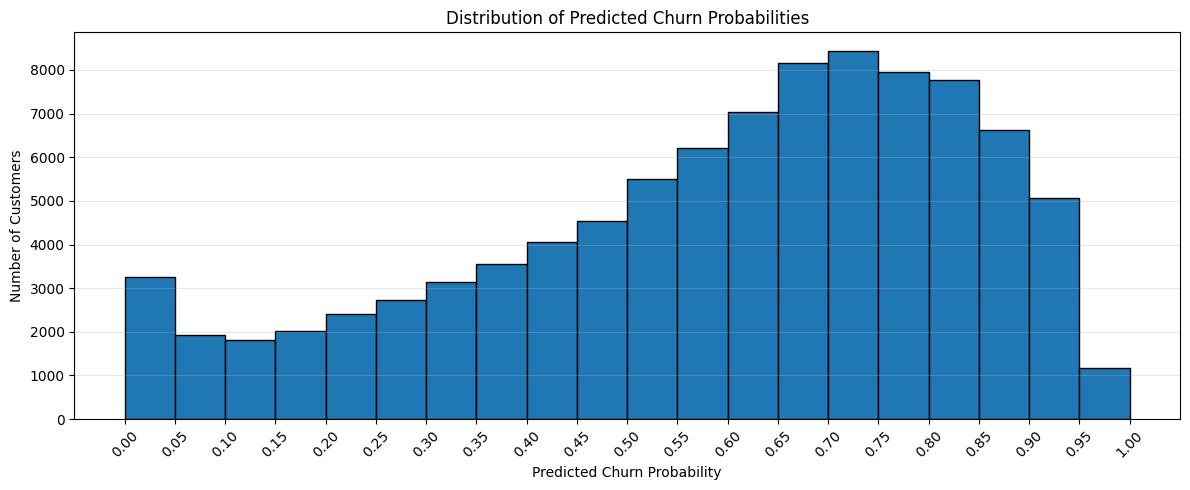

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

bins = np.arange(0, 1.05, 0.05)   # 0.00, 0.05, ..., 1.00

plt.hist(
    customer_features['churn_probability'],
    bins=bins,
    edgecolor='black'
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predicted Churn Probabilities")
plt.xticks(bins, rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:

high_risk = customer_features[(customer_features['churn_probability'] >= 0.6) & (customer_features['churn_probability'] < 0.8)]
critical_risk = customer_features[customer_features['churn_probability'] >= 0.8]


In [14]:
avg_order_value = customer_features['avg_order_value'].mean()
avg_order_value

np.float64(160.31543448142764)

In [16]:
#  REVENUE AT RISK CALCULATION



print("=" * 60)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)

print(f"\nHigh-risk customers (P(churn) >= 0.60 and < 0.80):")
print(f"  Count: {len(high_risk):,}")
print(f"  Total historical spend: R${high_risk['total_spend'].sum():,.0f}")
print(f"  Average spend per customer: R${high_risk['total_spend'].mean():,.0f}")

print(f"\nCritical-risk customers (P(churn) >= 0.80):")
print(f"  Count: {len(critical_risk):,}")
print(f"  Total historical spend: R${critical_risk['total_spend'].sum():,.0f}")
print(f"  Total historical average spend: R${critical_risk['total_spend'].mean():,.0f}")



BUSINESS IMPACT ANALYSIS

High-risk customers (P(churn) >= 0.60 and < 0.80):
  Count: 31,588
  Total historical spend: R$5,927,427
  Average spend per customer: R$188

Critical-risk customers (P(churn) >= 0.80):
  Count: 20,636
  Total historical spend: R$2,334,016
  Total historical average spend: R$113


In [21]:
high_risk["total_orders"].sum()/len(high_risk)

np.float64(1.025009497277447)

In [24]:
## A potential retention campaign 

# Assumption: If a high-value customer churns, we lose their expected future order

avg_order_value = high_risk['avg_order_value'].mean()
expected_annual_orders = 1.025  # conservative assumption:going by numbers
retention_rate=0.10

revenue_at_risk = len(high_risk) * avg_order_value * expected_annual_orders

print(f"\n{'='*60}")
print(f"ESTIMATED ANNUAL REVENUE AT RISK: R${revenue_at_risk:,.0f}")
print(f"{'='*60}")
print(f"\nAssumptions:")
print(f"  - Avg order value: R${avg_order_value:.0f}")
print(f"  - Expected orders/year: {expected_annual_orders}")
print(f"  - At-risk customers: {len(high_risk):,}")

# Retention campaign ROI

campaign_cost_per_customer = 10  # R$5 in discount/email cost

revenue_saved = len(high_risk) * retention_rate * avg_order_value * expected_annual_orders
campaign_cost = len(high_risk) * campaign_cost_per_customer
campaign_roi = (revenue_saved - campaign_cost) / campaign_cost * 100

print(f"\nRETENTION CAMPAIGN SCENARIO (15% retention rate):")
print(f"  Customers retained: {int(len(high_risk) * retention_rate):,}")
print(f"  Revenue saved: R${revenue_saved:,.0f}")
print(f"  Campaign cost: R${campaign_cost:,.0f}")
print(f"  Campaign ROI: {campaign_roi:.0f}%")


ESTIMATED ANNUAL REVENUE AT RISK: R$5,956,799

Assumptions:
  - Avg order value: R$184
  - Expected orders/year: 1.025
  - At-risk customers: 31,588

RETENTION CAMPAIGN SCENARIO (15% retention rate):
  Customers retained: 3,158
  Revenue saved: R$595,680
  Campaign cost: R$315,880
  Campaign ROI: 89%
